# البدء بالفيديو
##   الهدف:
ستتعلم بهذا الفصل كيفية عمل تابعين
`cv2.VideoCapture()` , `cv2.VideoWriter`   


##  التقاط الفيديو من الكاميرا:
احياناً نحتاج لاخذ الصور مباشرة من الكاميرا, ولذلك سنقوم بهذا هنا ومن ثم نحول الاطارات للمستوي الرمادي ونعرضه كمهمة بسيطة للبدء.
ولالتقاط فيديو تحتاج لجسم  يدعى  VideoCapture ودخله اما ترتيب الاداة او اسم ملف الفيديو , وغالباً الكاميرا الوحيدة ستملك الترتيب 0 او -1  وبعدها يمكنك التقاط كل اطار باطاره ولكن لاتنسى بالنهاية افلات جسم الالتقاط .

In [1]:
import cv2
import numpy as np

هنا تم استيراد مكتبة opencv  بالاضافة لل numpy  الضرورية للعمل مع مصفوفات الصور

In [ ]:

cap = cv2.VideoCapture(1)

while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()
    # print frame
    # convrt 2 gray
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    
    # display the result (try in page)
    cv2.imshow('frame',gray)
    
    if cv2.waitKey(1) == ord('q'):
        # in 64-bit machine add: & 0xFF above
        break
        
# at the end release every thing:
cap.release()
cv2.destroyAllWindows()

السابق , دخل في حلقة لقراءة الصور من الفيديو , ومن ثم إظهارها بنافذة ضمن opencv

`cap.read`
يعطي عددا بولانياً : اذا ماكان الاطار مقرؤاً بشكل صحيح 
 ولذلك يمكن معرفة نهاية الفيديو من ذلك

كما يمكن استخدام `cap.is_open` لمعرفة , هل المصدر للفيديو , قابل للقراءة   
كما يمكنك ايضاً الحصول على خصائص الفيديو من خلال التعليمة
`cap.get(ProbId)`

حيث نمرر رقم الخاصية ذو المجال من 0-18 كما نلاحظ ان بعض الخاصيات لديها قابلية القراءة والكتابة ايضاً عبر
أي أن كل رقم يعطي معلومة محددة عن جسم التقاط الصور cap
أما الأمر:
`cap.set(probId,value)`.  
يغير الخاصية ذات الترتيب propId  للقيمة المعطاة
مثلاً الطول والعرض للفيديو , نلاحظ انه قد يمكن تغييرهما ..


## : تشغيل الفيديو من ملف
مماثل لماسبق , فقط استبدل العنوان باسم الملف , وانتبه ايضاً للتابع
`cv2.waitKey`
بحيث تكون القيمة داخله مناسبة , والافسوف يعمل الفيديو بسرعة عالية جداً , او ببطء كبير جداً , عملياً قد يكون 25 ميلي ثانية مناسباً.
كما التالي:

In [12]:
import numpy as np
import cv2

cap = cv2.VideoCapture('F:\Videos1\sad1.mp4')

while(cap.isOpened()):
    ret, frame = cap.read()
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    cv2.imshow('frame',gray)
    if cv2.waitKey(1) == ord('q'):
        break
        
cap.release()
cv2.destroyAllWindows()

فيما لو لاحظتم تم تحويل الصورة لرمادية , ومن ثم بعد انتهاء حلقة `while` تم اغلاق جسم الفيديو, واغلاق النافذة , وهذا ضروري في openCV

##  حفظ الفيديو:
يتم ذلك عبر التعليمة 
`cv2.imwrite`.
وهنا نحتاج لبعض العمل 
اذ يجب تحديد اسم الفيديو الناتج , وكذلك شيفرة ال
`FourCC`
وكذلك عدد الاطارات بالثانية ,أما العلم  : 
`isColor`
فيما لو كان 1 فسيكون الفيديو بالالوان والا رمادي ..
`FourCC`اما 
هي لتشفير للفيديو وله عدة اعلام:

1. DIVX, XVID, MJPG, X264, WMV1, WMV2.بفيدورا 

2. ب وندوز DIVX .

الكود التالي يأخذ الاطارات من الكاميرا ويدور كل منها باتجاه افقي ويحفظه.


In [ ]:
import numpy as np
import cv2

cap = cv2.VideoCapture(0)

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
while(cap.isOpened()):
    ret, frame = cap.read()
    if ret==True:
        frame = cv2.flip(frame,0)
        
        # write the flipped frame
        out.write(frame)
        
        cv2.imshow('frame',frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break
        
# Release everything if job is finished
cap.release()
out.release()
cv2.destroyAllWindows()

#  توابع الرسم في OpenCV:
بكل توابع الرسم مثل :
`cv2.line() , cv2.circle() , cv2.rectangle(), cv2.ellipse(), cv2.putText()`
هناك عدد من المتغيرات نفسها: وهي:

1. الصورة : التي عليها يتم الرسم

2. tupleاللون : لون الشكل , من اجل   نمرر ثلاث قيم  .

3. السماكة ..(-1 تعني ممتلئ)

4. cv2.LINE_AA نوع الخط : اما 8-متصل أو ..



## رسم خط:
لرسم خط نحتاج لاحداثي البداية والنهاية للخط والمثال التالي يرسم خطاً قطرياً في الصورة.


In [4]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Create a black image
img = np.zeros((512,512,3), np.uint8)

# Draw a diagonal blue line with thickness of 5 px
img = cv2.line(img,(0,0),(511,511),(0,0,255),5)

# lets see 
plt.imshow(img)
plt.show()

TypeError: Image data can not convert to float

نلاحظ الخطأ اعلاه والسبب انه ......
لا يجوز اسناد الصورة للخرج في تابع
`cv2.line()`
يتم تمريرها فقط ومن ثم الرسم فوقها والخرج هو لا قيمة
None

ولاحظ مكتبة `matplotlib` التي تم استيرادها هنا , للرسم ,ومن ثم الرسم بالتابع `imshow` للصورة الصفرية , وإضافة الخط الازرق لها
 لذلك نصحح الكود كالتالي:

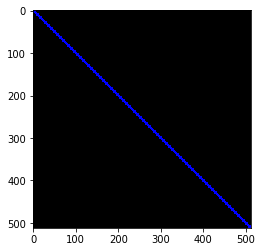

In [9]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Create a black image
img = np.zeros((512,512,3), np.uint8)

# Draw a diagonal blue line with thickness of 5 px
# & Don't assign it
cv2.line(img,(0,0),(511,511),(0,0,255),5)

# lets see 
plt.imshow(img)
plt.show()

##  رسم مستطيل:
نحتاج زاويته العليا اليسارية والدنيا اليمينية , التالي يرسم مستطيلاً اخضر على نفس الصورة

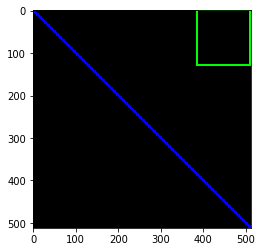

In [10]:
cv2.rectangle(img,(384,0),(510,128),(0,255,0),3)
# lets see 
plt.imshow(img)
plt.show()

## رسم دائرة
لرسم دائرة , تحتاج نصف قطرها ومركزها , وسنرسم دائرة داخل المستطيل اعلاه:

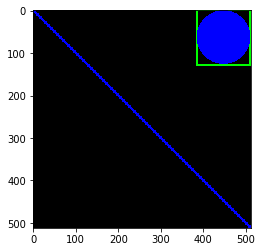

In [11]:
cv2.circle(img,(447,63), 63, (0,0,255), -1)
# lets see 
plt.imshow(img)
plt.show()

## رسم قطع ناقص:
لرسم قطع ناقص , نحتاج لتمرير عدة متغيرات , احداها هو مركزه , ومن ثم اطوال المحورين ومن ثم زاوية دورانه , ومن ثم (زاوية البداية والنهاية) اي من اين لاين يرسم القطع , عبر التابع  :
`cv2.ellipse`


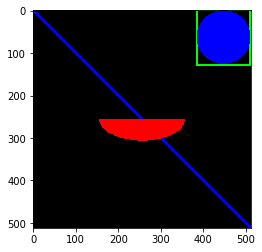

In [12]:
cv2.ellipse(img,(256,256),(100,50),0,0,180,255,-1)
plt.imshow(img)
plt.show()

##  رسم مضلع:
لرسم مضلع , اولاً نحتاج رؤوس الاحداثيات, .
ومن ثم نجعلها بشكل مصفوفة , بالشكل

$$ Rows \ X 1 \ X 2 $$

ويجب ان تكون بالصيغة
`int32` 
والتالي يرسم مضلعاً باربع رؤوس :

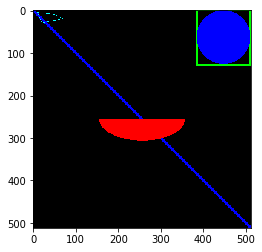

In [13]:
pts = np.array([[10,5],[20,30],[70,20],[50,10]], np.int32)
pts = pts.reshape((-1,1,2))
cv2.polylines(img,[pts],True,(0,255,255))
plt.imshow(img)
plt.show()


1.  لو كان الدخل الثالث   flase  لكنا حصلنا على مضلع مفتوح

2. يمكن للتابع السابق رسم عدة مستقيمات معاً , ماعليك الاتمرير مصفوفات النقاط وهذا افضل من رسم كل مستقيم على حدة.


##  اضافة نص للصورة:
لوضع النص بالصورة , عليك تحديد مايلي:

1. النص الذي تريد ادراجه.

2. موضع النص بالنسبة للصورة من زاويته السفلى اليسرى

3. نوع الخط `font-family` 

4. حجم الخط بالبكسل.

5. الامور المعتادة مثل السماكة , اللون , ...

وفيما يلي نص لعبارة :   وطريقة ادراجها بالصورة:


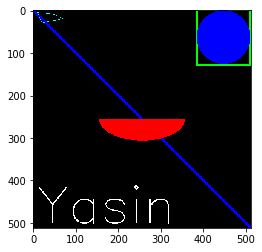

In [14]:
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img,'Yasin',(10,500), font, 4,(255,255,255),2)
plt.imshow(img)
plt.show()

### ملاحظة:
بالنسبة للغة العربية , الدعم غير متوفر للكتابة على الصور , المسألة بحاجة لعمل مختص..


##  النتيجة :
حان الوقت لاظهار الصورة النهائية :
لذلك نكتب

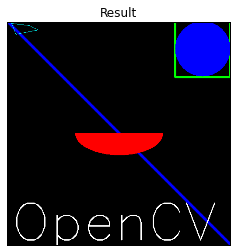

In [11]:
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title("Result")
plt.show()

## تمرين
حاول انشاء شعار 
opencv
بوساطة التعليمات السابقة التي تعلمتها..